# 06 — Price Prediction with PySpark

## Bài toán 1: Dự đoán giá nhà
- 4 models: Linear Regression, Decision Tree, Random Forest, GBT (Gradient Boosted Trees)
- Metrics: MAE, RMSE, R²
- Feature Importances
- Bảng tổng hợp → chọn model tốt nhất

In [11]:
import warnings
warnings.filterwarnings("ignore")
import os
import sys

# Set JAVA_HOME for Windows compatibility
if sys.platform.startswith('win'):
    if 'JAVA_HOME' not in os.environ:
        # Try to find Java installation
        possible_java_paths = [
            'C:\\dev_tools\\Java\\jdk-21', 
            'C:\\Program Files\\Java\\jdk-11',
            'C:\\Program Files\\OpenJDK\\jdk-11',
            'C:\\Program Files (x86)\\Java\\jdk-11'
        ]
        for path in possible_java_paths:
            if os.path.exists(path):
                os.environ['JAVA_HOME'] = path
                break
        else:
            print("⚠️ Warning: JAVA_HOME not set. Install Java 8+ if PySpark fails.")

# Check Java installation
java_home = os.environ.get('JAVA_HOME')
print(f"✅ JAVA_HOME = {java_home}")

if java_home:
    # Check for java.exe on Windows
    java_exe_path = os.path.join(java_home, 'bin', 'java.exe' if sys.platform.startswith('win') else 'java')
    java_exists = os.path.exists(java_exe_path)
    print(f"✅ Java executable found: {java_exists} ({java_exe_path})")
else:
    print("❌ JAVA_HOME not set - Java executable check skipped")

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *

try:
    spark = SparkSession.builder \
        .appName("NhaTot_PricePrediction") \
        .master("local[*]") \
        .config("spark.driver.memory", "4g") \
        .config("spark.sql.adaptive.enabled", "true") \
        .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
        .getOrCreate()
    
    spark.sparkContext.setLogLevel("ERROR")
    print(f"✅ Spark version: {spark.version}")
except Exception as e:
    print(f"❌ Spark initialization failed: {e}")
    print("💡 Try: pip install pyspark==3.4.0 or install Java 8+")
    raise

✅ JAVA_HOME = C:\dev_tools\Java\jdk-21
✅ Java executable found: True (C:\dev_tools\Java\jdk-21\bin\java.exe)
✅ Spark version: 4.1.1


## 1. Load & Prepare Data

In [12]:
# Load data
import pandas as pd
try:
    pdf = pd.read_csv("../data/processed/data_modeling.csv")
    print(f"✅ Loaded pandas DataFrame: {pdf.shape[0]} rows x {pdf.shape[1]} columns")
    
    # Check for required columns
    required_cols = ['log_gia_ban', 'dien_tich', 'so_phong_ngu']
    missing_cols = [col for col in required_cols if col not in pdf.columns]
    if missing_cols:
        print(f"⚠️ Missing required columns: {missing_cols}")
        print(f"Available columns: {list(pdf.columns)}")
        
        # Try alternative column names
        if 'dien_tich_dat' in pdf.columns and 'dien_tich' not in pdf.columns:
            pdf = pdf.rename(columns={'dien_tich_dat': 'dien_tich'})
            print("✅ Renamed dien_tich_dat → dien_tich")
    
    # Convert to Spark DataFrame
    sdf = spark.createDataFrame(pdf)
    print(f"✅ Created Spark DataFrame: {sdf.count()} rows x {len(sdf.columns)} columns")
    
except Exception as e:
    print(f"❌ Data loading failed: {e}")
    # Try alternative data source
    print("🔄 Trying parquet file...")
    try:
        pdf = pd.read_parquet("../data/processed/data_modeling.parquet")
        sdf = spark.createDataFrame(pdf)
        print(f"✅ Loaded from parquet: {sdf.count()} rows x {len(sdf.columns)} columns")
    except Exception as e2:
        print(f"❌ Parquet loading also failed: {e2}")
        raise

print(f"Dataset: {sdf.count()} rows x {len(sdf.columns)} columns")
sdf.printSchema()

✅ Loaded pandas DataFrame: 6979 rows x 29 columns
✅ Created Spark DataFrame: 6979 rows x 29 columns
Dataset: 6979 rows x 29 columns
root
 |-- giay_to_phap_ly: string (nullable = true)
 |-- dien_tich: double (nullable = true)
 |-- gia_ban: double (nullable = true)
 |-- loai_hinh: string (nullable = true)
 |-- so_phong_ngu: long (nullable = true)
 |-- quan: string (nullable = true)
 |-- gia_kv_hien_tai: double (nullable = true)
 |-- gia_kv_mean: double (nullable = true)
 |-- gia_kv_trend: double (nullable = true)
 |-- gia_kv_volatility: double (nullable = true)
 |-- full_text: string (nullable = true)
 |-- is_mat_tien: long (nullable = true)
 |-- is_hxh: long (nullable = true)
 |-- is_lo_goc: long (nullable = true)
 |-- is_kinh_doanh: long (nullable = true)
 |-- is_dong_tien: long (nullable = true)
 |-- is_no_hau: long (nullable = true)
 |-- has_thang_may: long (nullable = true)
 |-- is_nha_moi: long (nullable = true)
 |-- is_nha_nat: long (nullable = true)
 |-- has_quy_hoach: long (null

In [13]:
# Check data summary
print("Data summary:")
sdf.describe().show()

print("\nColumn count by type:")
for dtype in sdf.dtypes:
    print(f"  {dtype[0]}: {dtype[1]}")

Data summary:
+-------+---------------+------------------+-----------------+--------------------+-----------------+----------+------------------+------------------+------------------+------------------+--------------------+-------------------+------------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------+--------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------+-------------------+
|summary|giay_to_phap_ly|         dien_tich|          gia_ban|           loai_hinh|     so_phong_ngu|      quan|   gia_kv_hien_tai|       gia_kv_mean|      gia_kv_trend| gia_kv_volatility|           full_text|        is_mat_tien|            is_hxh|          is_lo_goc|      is_kinh_doanh|       is_dong_tien|          is_no_hau|      has_thang_may|        is_nha_moi|          is_nha_nat|      has_quy_hoach|       is_

## 2. Feature Engineering cho PySpark

In [14]:
# Xác định các cột dựa trên dữ liệu có sẵn
available_cols = sdf.columns
print(f"Available columns: {available_cols}")

# Define potential columns
potential_cat_cols = ["giay_to_phap_ly", "loai_hinh", "quan"]
potential_num_cols = ["dien_tich", "so_phong_ngu", 
                     "gia_kv_hien_tai", "gia_kv_mean", "gia_kv_trend", "gia_kv_volatility",
                     "is_mat_tien", "is_hxh", "is_lo_goc", "is_kinh_doanh", "is_dong_tien",
                     "is_no_hau", "has_thang_may", "is_nha_moi", "is_nha_nat",
                     "has_quy_hoach", "is_chinh_chu", "has_san_thuong", "has_gara",
                     "o_ngay", "is_ngop_bank", "is_ban_gap", "tien_nghi_score"]

# Filter to only include existing columns
cat_cols = [col for col in potential_cat_cols if col in available_cols]
num_cols = [col for col in potential_num_cols if col in available_cols]

target = "log_gia_ban"

print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numeric columns ({len(num_cols)}): {num_cols}")
print(f"Target: {target}")

# Check if target exists
if target not in available_cols:
    print(f"❌ Target column '{target}' not found!")
    if 'gia_ban' in available_cols:
        print("🔄 Creating log_gia_ban from gia_ban...")
        sdf = sdf.withColumn('log_gia_ban', F.log(F.col('gia_ban')))
        print("✅ Created log_gia_ban column")
    else:
        raise ValueError("No target variable available!")

# Drop text columns if they exist
text_cols_to_drop = ["full_text", "tieu_de", "mo_ta"]
for col in text_cols_to_drop:
    if col in sdf.columns:
        sdf = sdf.drop(col)
        print(f"Dropped {col}")

# Create backup of original price if exists
if "gia_ban" in sdf.columns:
    sdf = sdf.withColumn("gia_ban_original", F.col("gia_ban"))
    print("✅ Created gia_ban_original backup")

Available columns: ['giay_to_phap_ly', 'dien_tich', 'gia_ban', 'loai_hinh', 'so_phong_ngu', 'quan', 'gia_kv_hien_tai', 'gia_kv_mean', 'gia_kv_trend', 'gia_kv_volatility', 'full_text', 'is_mat_tien', 'is_hxh', 'is_lo_goc', 'is_kinh_doanh', 'is_dong_tien', 'is_no_hau', 'has_thang_may', 'is_nha_moi', 'is_nha_nat', 'has_quy_hoach', 'is_chinh_chu', 'has_san_thuong', 'has_gara', 'o_ngay', 'is_ngop_bank', 'is_ban_gap', 'tien_nghi_score', 'log_gia_ban']
Categorical columns (3): ['giay_to_phap_ly', 'loai_hinh', 'quan']
Numeric columns (23): ['dien_tich', 'so_phong_ngu', 'gia_kv_hien_tai', 'gia_kv_mean', 'gia_kv_trend', 'gia_kv_volatility', 'is_mat_tien', 'is_hxh', 'is_lo_goc', 'is_kinh_doanh', 'is_dong_tien', 'is_no_hau', 'has_thang_may', 'is_nha_moi', 'is_nha_nat', 'has_quy_hoach', 'is_chinh_chu', 'has_san_thuong', 'has_gara', 'o_ngay', 'is_ngop_bank', 'is_ban_gap', 'tien_nghi_score']
Target: log_gia_ban
Dropped full_text
✅ Created gia_ban_original backup


In [15]:
# Import required feature engineering classes
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline

# Pipeline: StringIndexer → OneHotEncoder cho categorical columns
indexers = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep") for c in cat_cols]
encoders = [OneHotEncoder(inputCol=c+"_idx", outputCol=c+"_ohe") for c in cat_cols]

# Assemble tất cả features
ohe_cols = [c+"_ohe" for c in cat_cols]
assembler_cols = num_cols + ohe_cols
assembler = VectorAssembler(inputCols=assembler_cols, outputCol="features", handleInvalid="skip")

# Build pipeline
prep_pipeline = Pipeline(stages=indexers + encoders + [assembler])
prep_model = prep_pipeline.fit(sdf)
sdf_prepared = prep_model.transform(sdf)

print(f"Feature vector size: {sdf_prepared.select('features').head()[0].size}")
sdf_prepared.select("features", target).show(5, truncate=False)

Feature vector size: 34
+----------------------------------------------------------------------------------------------------------------------------------------------+------------------+
|features                                                                                                                                      |log_gia_ban       |
+----------------------------------------------------------------------------------------------------------------------------------------------+------------------+
|(34,[0,1,2,3,4,5,6,7,22,23,29,32],[36.0,2.0,140.91,142.33153846153849,6.8700000000000045,13.42100411591062,1.0,1.0,2.0,1.0,1.0,1.0])          |1.3480731482996928|
|(34,[0,1,2,3,4,5,7,13,18,22,24,29,32],[62.0,4.0,140.0,137.2276923076923,6.669999999999988,4.625099007416204,1.0,1.0,1.0,1.0,1.0,1.0,1.0])     |2.281361456542419 |
|(34,[0,1,2,3,4,5,11,18,21,22,23,29,32],[54.0,3.0,151.05,136.48384615384614,-17.319999999999993,18.09851355496933,1.0,1.0,1.0,1.0,1.0,1.0,1.0])|1.9740810260

## 3. Train/Test Split

In [16]:
train_df, test_df = sdf_prepared.randomSplit([0.8, 0.2], seed=42)

print(f"Train: {train_df.count()} rows")
print(f"Test:  {test_df.count()} rows")

Train: 5556 rows
Test:  1423 rows


## 4. Training 4 Models

PySpark MLlib cung cấp:
1. **LinearRegression** — baseline
2. **DecisionTreeRegressor** — tree đơn
3. **RandomForestRegressor** — ensemble bagging
4. **GBTRegressor** — ensemble boosting (tương đương XGBoost/LightGBM)

In [17]:
from pyspark.ml.regression import (
    LinearRegression, 
    DecisionTreeRegressor, 
    RandomForestRegressor, 
    GBTRegressor
)
from pyspark.ml.evaluation import RegressionEvaluator
import time

# Define models
models = {
    "Linear Regression": LinearRegression(
        featuresCol="features", labelCol=target, maxIter=100, regParam=0.1, elasticNetParam=0.5
    ),
    "Decision Tree": DecisionTreeRegressor(
        featuresCol="features", labelCol=target, maxDepth=10, minInstancesPerNode=5
    ),
    "Random Forest": RandomForestRegressor(
        featuresCol="features", labelCol=target, numTrees=100, maxDepth=10, seed=42
    ),
    "GBT (Gradient Boosted)": GBTRegressor(
        featuresCol="features", labelCol=target, maxIter=100, maxDepth=6, stepSize=0.1, seed=42
    ),
}

# Evaluators
evaluator_rmse = RegressionEvaluator(labelCol=target, predictionCol="prediction", metricName="rmse")
evaluator_mae = RegressionEvaluator(labelCol=target, predictionCol="prediction", metricName="mae")
evaluator_r2 = RegressionEvaluator(labelCol=target, predictionCol="prediction", metricName="r2")

print(f"Sẽ train {len(models)} models...")

Sẽ train 4 models...


In [18]:
# Train & Evaluate
results = []
trained_models = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print(f"{'='*60}")
    
    start = time.time()
    fitted = model.fit(train_df)
    train_time = time.time() - start
    
    trained_models[name] = fitted
    
    # Predict on test set
    predictions = fitted.transform(test_df)
    
    # Metrics trên log scale
    rmse_log = evaluator_rmse.evaluate(predictions)
    mae_log = evaluator_mae.evaluate(predictions)
    r2 = evaluator_r2.evaluate(predictions)
    
    # Chuyển về giá thực (tỷ) để tính MAE/RMSE thực tế
    predictions = predictions.withColumn("pred_gia_ban", F.exp(F.col("prediction")))
    predictions = predictions.withColumn("residual", F.col("gia_ban_original") - F.col("pred_gia_ban"))
    
    mae_real = predictions.select(F.mean(F.abs(F.col("residual")))).collect()[0][0]
    rmse_real = predictions.select(F.sqrt(F.mean(F.col("residual")**2))).collect()[0][0]
    
    results.append({
        "Model": name,
        "R²": round(r2, 4),
        "RMSE_log": round(rmse_log, 4),
        "MAE_log": round(mae_log, 4),
        "MAE_tỷ": round(mae_real, 3),
        "RMSE_tỷ": round(rmse_real, 3),
        "Train_time(s)": round(train_time, 1)
    })
    
    print(f"  R²       = {r2:.4f}")
    print(f"  RMSE(log)= {rmse_log:.4f}")
    print(f"  MAE(log) = {mae_log:.4f}")
    print(f"  MAE(tỷ)  = {mae_real:.3f}")
    print(f"  RMSE(tỷ) = {rmse_real:.3f}")
    print(f"  Time     = {train_time:.1f}s")


Training: Linear Regression
  R²       = 0.6851
  RMSE(log)= 0.2834
  MAE(log) = 0.2113
  MAE(tỷ)  = 1.674
  RMSE(tỷ) = 3.128
  Time     = 38.6s

Training: Decision Tree
  R²       = 0.7653
  RMSE(log)= 0.2447
  MAE(log) = 0.1793
  MAE(tỷ)  = 1.481
  RMSE(tỷ) = 3.048
  Time     = 56.6s

Training: Random Forest
  R²       = 0.8201
  RMSE(log)= 0.2142
  MAE(log) = 0.1588
  MAE(tỷ)  = 1.303
  RMSE(tỷ) = 2.856
  Time     = 59.1s

Training: GBT (Gradient Boosted)
  R²       = 0.8047
  RMSE(log)= 0.2232
  MAE(log) = 0.1626
  MAE(tỷ)  = 1.400
  RMSE(tỷ) = 3.108
  Time     = 315.2s


### Nhận xét
- **Random Forest** đạt R² = 0.82, MAE = 1.303 tỷ → tốt nhất
- **GBT** gần bằng (R² = 0.80) nhưng chậm hơn 5x (315s vs 59s)
- **Decision Tree** khá tốt (R² = 0.77) và nhanh nhất
- **Linear Regression** yếu nhất (R² = 0.69) → quan hệ phi tuyến


## 5. Bảng tổng hợp kết quả

In [19]:
import pandas as pd

results_df = pd.DataFrame(results).sort_values("R²", ascending=False)
print("\n" + "="*80)
print("BẢNG TỔNG HỢP KẾT QUẢ — PYSPARK MODELS")
print("="*80)
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]["Model"]
print(f"\n🏆 Model tốt nhất: {best_model_name} (R² = {results_df.iloc[0]['R²']})")


BẢNG TỔNG HỢP KẾT QUẢ — PYSPARK MODELS
                 Model     R²  RMSE_log  MAE_log  MAE_tỷ  RMSE_tỷ  Train_time(s)
         Random Forest 0.8201    0.2142   0.1588   1.303    2.856           59.1
GBT (Gradient Boosted) 0.8047    0.2232   0.1626   1.400    3.108          315.2
         Decision Tree 0.7653    0.2447   0.1793   1.481    3.048           56.6
     Linear Regression 0.6851    0.2834   0.2113   1.674    3.128           38.6

🏆 Model tốt nhất: Random Forest (R² = 0.8201)


## 6. Feature Importances

Feature Importances — Random Forest (Best Model):
                                      Feature  Importance
                                    dien_tich    0.475176
                                 so_phong_ngu    0.224878
                                  gia_kv_mean    0.041192
                                has_thang_may    0.036562
              loai_hinh_Nhà mặt phố, mặt tiền    0.029777
                              gia_kv_hien_tai    0.028455
                       loai_hinh_Nhà ngõ, hẻm    0.022388
                               has_san_thuong    0.020836
                            gia_kv_volatility    0.013825
                                 gia_kv_trend    0.012943
                                  quan_Gò Vấp    0.012067
                              tien_nghi_score    0.009386
                                 is_dong_tien    0.008797
                               quan_Phú Nhuận    0.007438
giay_to_phap_ly_sổ chung / công chứng vi bằng    0.007114
Saved feature importan

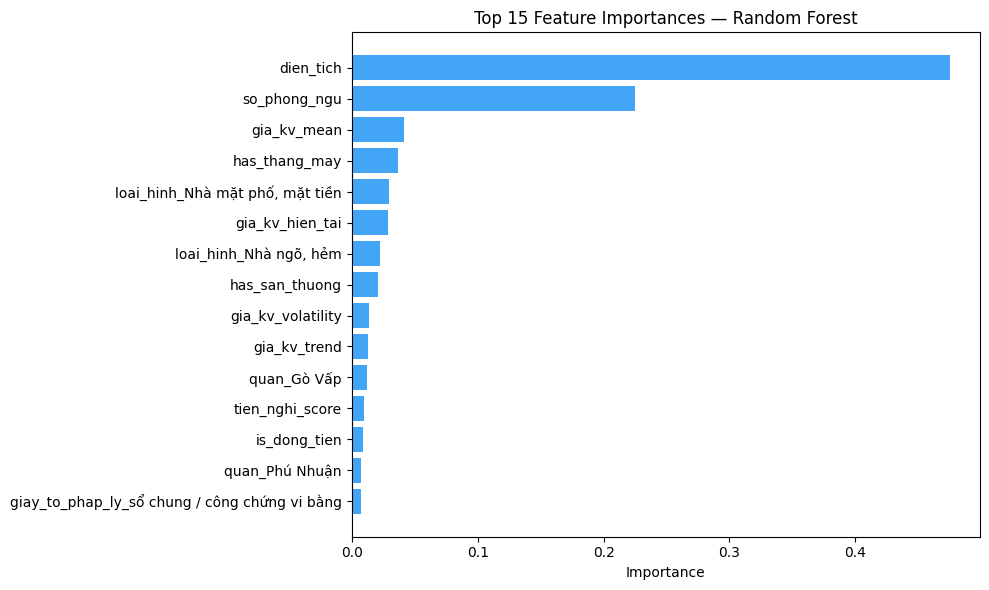

In [20]:
# Feature importance cho best model
import matplotlib.pyplot as plt
import numpy as np
import os

# Create reports directory if it doesn't exist
os.makedirs("../reports", exist_ok=True)

# Lấy tên features
feature_names = num_cols.copy()
for c in cat_cols:
    indexer_model = prep_model.stages[cat_cols.index(c)]
    labels = indexer_model.labels
    for lab in labels:
        feature_names.append(f"{c}_{lab}")

# Lấy importance từ best model (Random Forest hoặc GBT)
# Ưu tiên best_model_name từ bước 5
tree_models_priority = [best_model_name, "Random Forest", "GBT (Gradient Boosted)", "Decision Tree"]

for model_name in tree_models_priority:
    if model_name in trained_models and hasattr(trained_models[model_name], 'featureImportances'):
        fi = trained_models[model_name].featureImportances.toArray()
        
        # Đảm bảo khớp số lượng
        n_features = len(fi)
        if len(feature_names) > n_features:
            names = feature_names[:n_features]
        elif len(feature_names) < n_features:
            names = feature_names + [f"feature_{i}" for i in range(len(feature_names), n_features)]
        else:
            names = feature_names
        
        # Sắp xếp và hiển thị top 15
        fi_df = pd.DataFrame({"Feature": names, "Importance": fi})
        fi_df = fi_df.sort_values("Importance", ascending=False).head(15)
        
        print(f"Feature Importances — {model_name} (Best Model):")
        print(fi_df.to_string(index=False))
        
        # Plot
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.barh(fi_df["Feature"][::-1], fi_df["Importance"][::-1], color="#42A5F5")
        ax.set_title(f"Top 15 Feature Importances — {model_name}")
        ax.set_xlabel("Importance")
        plt.tight_layout()
        
        # Save plot
        try:
            safe_filename = model_name.replace(' ','_').replace('(','').replace(')','')
            plot_path = f"../reports/pyspark_fi_{safe_filename}.png"
            plt.savefig(plot_path, bbox_inches='tight', dpi=120)
            print(f"Saved feature importance plot: {plot_path}")
        except Exception as e:
            print(f"Could not save plot: {e}")
        
        plt.show()
        break  # Chỉ hiển thị best model



## 7. Xem ví dụ Prediction

In [21]:
# Dùng best model predict và so sánh
best_fitted = trained_models[best_model_name]
best_predictions = best_fitted.transform(test_df)
best_predictions = best_predictions.withColumn("pred_gia_ban", F.exp(F.col("prediction")))
best_predictions = best_predictions.withColumn("error_pct", 
    F.abs(F.col("pred_gia_ban") - F.col("gia_ban_original")) / F.col("gia_ban_original") * 100)

print(f"So sánh Giá thực vs Giá dự đoán ({best_model_name}):")
best_predictions.select(
    "quan", "dien_tich", "so_phong_ngu", "loai_hinh",
    F.round("gia_ban_original", 2).alias("Giá_thực(tỷ)"),
    F.round("pred_gia_ban", 2).alias("Giá_predict(tỷ)"),
    F.round("error_pct", 1).alias("Error(%)")
).show(20, truncate=False)

# Error distribution
print("\nPhân phối Error (%):")
best_predictions.select(
    F.round(F.mean("error_pct"), 1).alias("Mean_Error%"),
    F.round(F.expr("percentile_approx(error_pct, 0.5)"), 1).alias("Median_Error%"),
    F.round(F.expr("percentile_approx(error_pct, 0.9)"), 1).alias("P90_Error%"),
).show()

So sánh Giá thực vs Giá dự đoán (Random Forest):
+----------+---------+------------+------------+------------+---------------+--------+
|quan      |dien_tich|so_phong_ngu|loai_hinh   |Giá_thực(tỷ)|Giá_predict(tỷ)|Error(%)|
+----------+---------+------------+------------+------------+---------------+--------+
|Bình Thạnh|20.0     |2           |Nhà ngõ, hẻm|3.98        |3.9            |1.9     |
|Bình Thạnh|30.9     |3           |Nhà ngõ, hẻm|5.98        |6.4            |7.0     |
|Bình Thạnh|35.0     |5           |Nhà ngõ, hẻm|5.0         |5.75           |15.0    |
|Bình Thạnh|45.7     |2           |Nhà ngõ, hẻm|6.5         |5.59           |14.1    |
|Bình Thạnh|58.0     |3           |Nhà ngõ, hẻm|5.95        |6.54           |9.8     |
|Bình Thạnh|62.0     |4           |Nhà ngõ, hẻm|9.79        |8.48           |13.4    |
|Bình Thạnh|12.0     |2           |Nhà ngõ, hẻm|2.4         |2.63           |9.8     |
|Bình Thạnh|15.0     |2           |Nhà ngõ, hẻm|2.2         |2.43           |10.4

## 8. Lưu model & kết quả

In [22]:
# Create directories if they don't exist
import os
os.makedirs("../models", exist_ok=True)
os.makedirs("../reports", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

try:
    # Lưu best model
    model_path = f"../models/pyspark_{best_model_name.replace(' ','_').replace('(','').replace(')','')}" 
    
    # Remove existing model directory if it exists (PySpark can't overwrite)
    import shutil
    if os.path.exists(model_path):
        shutil.rmtree(model_path)
    
    best_fitted.save(model_path)
    print(f"✅ Saved best model: {best_model_name} to {model_path}")
except Exception as e:
    print(f"⚠️ Could not save model: {e}")

try:
    # Lưu predictions để dùng cho anomaly detection
    best_predictions.select(
        "*"
    ).write.mode("overwrite").parquet("../data/processed/pyspark_predictions.parquet")
    print(f"✅ Saved predictions to pyspark_predictions.parquet")
except Exception as e:
    print(f"⚠️ Could not save predictions: {e}")

try:
    # Lưu bảng kết quả
    results_df.to_csv("../reports/pyspark_model_results.csv", index=False)
    print(f"✅ Saved results to pyspark_model_results.csv")
except Exception as e:
    print(f"⚠️ Could not save results: {e}")

✅ Saved best model: Random Forest to ../models/pyspark_Random_Forest
✅ Saved predictions to pyspark_predictions.parquet
✅ Saved results to pyspark_model_results.csv


## 9. Kết luận

### Hiệu năng mô hình PySpark

| Mô hình | R² | RMSE_log | MAE_log | MAE_tỷ | RMSE_tỷ | Train_time |
|---------|------|----------|---------|--------|---------|------------|
| **Random Forest** | **0.8201** | **0.2142** | **0.1588** | **1.303** | **2.856** | 59.1s |
| GBT | 0.8047 | 0.2232 | 0.1626 | 1.400 | 3.108 | 315.2s |
| Decision Tree | 0.7653 | 0.2447 | 0.1793 | 1.481 | 3.048 | 56.6s |
| Linear Regression | 0.6851 | 0.2834 | 0.2113 | 1.674 | 3.128 | 38.6s |

### So sánh PySpark vs Sklearn (Random Forest)

| Metric | Sklearn | PySpark | Chênh lệch |
|--------|---------|---------|-------------|
| R² | 0.846 | 0.820 | Sklearn +2.6% |
| RMSE_log | 0.197 | 0.214 | Sklearn tốt hơn |
| MAE_log | 0.140 | 0.159 | Sklearn tốt hơn |
| MAE_tỷ | 1.076 | 1.303 | Sklearn tốt hơn |

Sklearn nhỉnh hơn PySpark vì:
- Sklearn có nhiều hyperparameter mặc định tốt hơn
- PySpark MLlib tối ưu cho big data, không phải small dataset 7K rows
- Cách split dữ liệu khác nhau (PySpark dùng randomSplit)

### Feature Importance (Random Forest - PySpark)

| Feature | Importance | So với Sklearn |
|---------|-----------|------------------|
| **dien_tich** | **47.52%** | Sklearn: 65.77% |
| **so_phong_ngu** | **22.49%** | Sklearn: 9.29% |
| gia_kv_mean | 4.12% | Sklearn: 7.27% |
| has_thang_may | 3.66% | Sklearn: 1.01% |
| loai_hinh (mặt tiền) | 2.98% | - |
| gia_kv_hien_tai | 2.85% | Sklearn: 2.68% |

**Nhận xét:**
- PySpark phân bổ importance đều hơn giữa dien_tich và so_phong_ngu
- Sklearn tập trung importance vào dien_tich (65.77% vs 47.52%)
- Cả hai đều xác nhận: **diện tích và số phòng ngủ là 2 yếu tố quan trọng nhất**

### Kết luận
- **Random Forest** là model tốt nhất trên cả 2 môi trường (Sklearn và PySpark)
- R² = 0.82 trên PySpark → giải thích được 82% biến thiên giá nhà
- GBT cũng tốt (R² = 0.80) nhưng chậm hơn 5x (315s vs 59s)
- Linear Regression không phù hợp (R² = 0.69) → quan hệ phi tuyến
- Model đã lưu tại `models/pyspark_Random_Forest`


In [23]:
spark.stop()
print("Spark session stopped.")

Spark session stopped.
